<a href="https://colab.research.google.com/github/kietkorangicsmsrm515-sketch/building-vibration-mode-analyser-/blob/main/vibraX_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# BUILDING VIBRATION MODE ANALYZER (B1)
# B.Tech Mathematics Mini Project
# ============================================================

"""
PROJECT TITLE:
Building Vibration Mode Analyzer (B1)

PROBLEM STATEMENT:
Model a 3-floor building as a mass-spring system.

The stiffness matrix K and mass matrix M give the
generalized eigenvalue problem:

                    K v = omega^2 M v

Find:
1. The 3 natural frequencies
2. The 3 eigenvalues
3. The 3 mode shapes (eigenvectors)
4. Show how each floor moves in each mode

MATHEMATICAL CONCEPT:
Eigenvalues and generalized eigenvectors

REAL-WORLD CONTEXT:
Earthquake engineering and structural vibration analysis.

ENVIRONMENT:
Google Colab + Python
NumPy + SciPy + SymPy + Matplotlib
"""

'\nPROJECT TITLE:\nBuilding Vibration Mode Analyzer (B1)\n\nPROBLEM STATEMENT:\nModel a 3-floor building as a mass-spring system.\n\nThe stiffness matrix K and mass matrix M give the\ngeneralized eigenvalue problem:\n\n                    K v = omega^2 M v\n\nFind:\n1. The 3 natural frequencies\n2. The 3 eigenvalues\n3. The 3 mode shapes (eigenvectors)\n4. Show how each floor moves in each mode\n\nMATHEMATICAL CONCEPT:\nEigenvalues and generalized eigenvectors\n\nREAL-WORLD CONTEXT:\nEarthquake engineering and structural vibration analysis.\n\nENVIRONMENT:\nGoogle Colab + Python\nNumPy + SciPy + SymPy + Matplotlib\n'

In [ ]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

# NumPy: numerical calculations and matrices
import numpy as np

# SymPy: symbolic mathematics
import sympy as sp

# SciPy: accurate generalized eigenvalue solver
from scipy.linalg import eigh

# Matplotlib: graphs and visualization
import matplotlib.pyplot as plt

# Pandas: clean result tables
import pandas as pd

# Display options
np.set_printoptions(precision=6, suppress=True)

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# ============================================================
# CELL 3: USER CONFIGURATION
# ============================================================

# ------------------------------------------------------------
# NUMBER OF FLOORS
# ------------------------------------------------------------

n_floors = 3


# ------------------------------------------------------------
# FLOOR MASSES
# Unit: kg
#
# Example:
# Floor 1 = 20,000 kg
# Floor 2 = 20,000 kg
# Floor 3 = 15,000 kg
# ------------------------------------------------------------

masses = np.array([
    20_000,
    20_000,
    15_000
], dtype=float)


# ------------------------------------------------------------
# STORY STIFFNESSES
# Unit: N/m
#
# k1 = stiffness between ground and Floor 1
# k2 = stiffness between Floor 1 and Floor 2
# k3 = stiffness between Floor 2 and Floor 3
# ------------------------------------------------------------

story_stiffness = np.array([
    8_000_000,
    7_000_000,
    5_000_000
], dtype=float)


# ------------------------------------------------------------
# OPTIONAL FLOOR HEIGHTS
# Unit: metres
# These are used only for visualization.
# ------------------------------------------------------------

floor_heights = np.array([
    3.0,
    6.0,
    9.0
], dtype=float)


# ------------------------------------------------------------
# BASIC INPUT VALIDATION
# ------------------------------------------------------------

if len(masses) != n_floors:
    raise ValueError("Number of masses must equal number of floors.")

if len(story_stiffness) != n_floors:
    raise ValueError(
        "For a fixed-base 3-floor shear building, "
        "provide one stiffness value for each story."
    )

if len(floor_heights) != n_floors:
    raise ValueError("Number of floor heights must equal number of floors.")

if np.any(masses <= 0):
    raise ValueError("All masses must be positive.")

if np.any(story_stiffness <= 0):
    raise ValueError("All story stiffness values must be positive.")

print("INPUT DATA")
print("=" * 50)

print(f"Number of floors: {n_floors}")

print("\nFloor masses:")
for i, mass in enumerate(masses, start=1):
    print(f"  Floor {i}: {mass:,.0f} kg")

print("\nStory stiffness:")
for i, k in enumerate(story_stiffness, start=1):
    print(f"  Story {i}: {k:,.0f} N/m")

print("\nInput validation: PASSED")

INPUT DATA
Number of floors: 3

Floor masses:
  Floor 1: 20,000 kg
  Floor 2: 20,000 kg
  Floor 3: 15,000 kg

Story stiffness:
  Story 1: 8,000,000 N/m
  Story 2: 7,000,000 N/m
  Story 3: 5,000,000 N/m

Input validation: PASSED


In [ ]:
# ============================================================
# CELL 4: PHYSICAL MODEL
# ============================================================

print("""
3-FLOOR SHEAR BUILDING MODEL

              Floor 3
          ───────────────
                │
               k3
                │
              Floor 2
          ───────────────
                │
               k2
                │
              Floor 1
          ───────────────
                │
               k1
                │
          ═══════════════
               GROUND

Each floor has one horizontal displacement:

    u1 = displacement of Floor 1
    u2 = displacement of Floor 2
    u3 = displacement of Floor 3

The displacement vector is:

    u = [u1, u2, u3]^T

The free-vibration equation is:

    M u'' + K u = 0

Assuming harmonic motion:

    u(t) = v sin(omega*t)

gives:

    K v = omega^2 M v
""")


3-FLOOR SHEAR BUILDING MODEL

              Floor 3
          ───────────────
                │
               k3
                │
              Floor 2
          ───────────────
                │
               k2
                │
              Floor 1
          ───────────────
                │
               k1
                │
          ═══════════════
               GROUND

Each floor has one horizontal displacement:
    
    u1 = displacement of Floor 1
    u2 = displacement of Floor 2
    u3 = displacement of Floor 3

The displacement vector is:

    u = [u1, u2, u3]^T

The free-vibration equation is:

    M u'' + K u = 0

Assuming harmonic motion:

    u(t) = v sin(omega*t)

gives:

    K v = omega^2 M v



In [ ]:
# ============================================================
# CELL 5: CONSTRUCT MASS MATRIX
# ============================================================

# For a lumped-mass shear building,
# the mass matrix is diagonal.

M = np.diag(masses)

print("MASS MATRIX M")
print("=" * 50)
print(M)
print("\nUnits: kg")

MASS MATRIX M
[[20000.     0.     0.]
 [    0. 20000.     0.]
 [    0.     0. 15000.]]

Units: kg


In [ ]:
# ============================================================
# CELL 6: CONSTRUCT STIFFNESS MATRIX
# ============================================================

def build_stiffness_matrix(story_stiffness):
    """
    Construct the stiffness matrix for a fixed-base
    shear-building model.

    For 3 floors:

        K11 = k1 + k2
        K12 = -k2
        K13 = 0

        K21 = -k2
        K22 = k2 + k3
        K23 = -k3

        K31 = 0
        K32 = -k3
        K33 = k3
    """

    n = len(story_stiffness)

    K = np.zeros((n, n), dtype=float)

    # Assemble the contribution of every story spring.
    for i in range(n):

        k = story_stiffness[i]

        if i == 0:
            # First story is connected to fixed ground.
            K[i, i] += k

        else:
            # Spring between floor i and floor i+1
            K[i-1, i-1] += k
            K[i, i] += k

            K[i-1, i] -= k
            K[i, i-1] -= k

    return K


K = build_stiffness_matrix(story_stiffness)

print("STIFFNESS MATRIX K")
print("=" * 50)
print(K)
print("\nUnits: N/m")

STIFFNESS MATRIX K
[[15000000. -7000000.        0.]
 [-7000000. 12000000. -5000000.]
 [       0. -5000000.  5000000.]]

Units: N/m


In [ ]:
# ============================================================
# CELL 7: DISPLAY M AND K AS TABLES
# ============================================================

floor_labels = [f"Floor {i}" for i in range(1, n_floors + 1)]

M_table = pd.DataFrame(
    M,
    index=floor_labels,
    columns=floor_labels
)

K_table = pd.DataFrame(
    K,
    index=floor_labels,
    columns=floor_labels
)

print("MASS MATRIX M")
display(M_table.style.format("{:,.2f}"))

print("\nSTIFFNESS MATRIX K")
display(K_table.style.format("{:,.2f}"))

MASS MATRIX M


,Floor 1,Floor 2,Floor 3
Floor 1,"20,000.00",0.00,0.00
Floor 2,0.00,"20,000.00",0.00
Floor 3,0.00,0.00,"15,000.00"



STIFFNESS MATRIX K


,Floor 1,Floor 2,Floor 3
Floor 1,"15,000,000.00","-7,000,000.00",0.00
Floor 2,"-7,000,000.00","12,000,000.00","-5,000,000.00"
Floor 3,0.00,"-5,000,000.00","5,000,000.00"


In [ ]:
# ============================================================
# CELL 8: MATRIX CHECKS
# ============================================================

print("MATRIX VALIDATION")
print("=" * 50)

# Check symmetry
print("Is M symmetric? :", np.allclose(M, M.T))
print("Is K symmetric? :", np.allclose(K, K.T))

# Check eigenvalues of M
mass_eigenvalues = np.linalg.eigvalsh(M)

# Check eigenvalues of K
stiffness_eigenvalues = np.linalg.eigvalsh(K)

print("\nEigenvalues of M:")
print(mass_eigenvalues)

print("\nEigenvalues of K:")
print(stiffness_eigenvalues)

# M should be positive definite for positive floor masses.
if np.all(mass_eigenvalues > 0):
    print("\nM is positive definite: PASSED")
else:
    raise ValueError("M must be positive definite.")

# K should be positive definite for a stable fixed-base model.
if np.all(stiffness_eigenvalues > 0):
    print("K is positive definite: PASSED")
else:
    raise ValueError(
        "K is not positive definite. Check the building model."
    )

MATRIX VALIDATION
Is M symmetric? : True
Is K symmetric? : True

Eigenvalues of M:
[15000. 20000. 20000.]

Eigenvalues of K:
[ 1416426.096584  9278624.690465 21304949.212951]

M is positive definite: PASSED
K is positive definite: PASSED


In [ ]:
# ============================================================
# CELL 9: MATHEMATICAL FORMULATION
# ============================================================

print("GENERALIZED EIGENVALUE PROBLEM")
print("=" * 60)

print("""
We need to solve:

             K v = lambda M v

where:

             lambda = omega^2

Therefore:

             omega = sqrt(lambda)

and natural frequency in Hz is:

             f = omega / (2*pi)
""")

print("Matrix K:")
print(K)

print("\nMatrix M:")
print(M)

GENERALIZED EIGENVALUE PROBLEM

We need to solve:

             K v = lambda M v

where:

             lambda = omega^2

Therefore:

             omega = sqrt(lambda)

and natural frequency in Hz is:

             f = omega / (2*pi)

Matrix K:
[[15000000. -7000000.        0.]
 [-7000000. 12000000. -5000000.]
 [       0. -5000000.  5000000.]]

Matrix M:
[[20000.     0.     0.]
 [    0. 20000.     0.]
 [    0.     0. 15000.]]


In [ ]:
# ============================================================
# CELL 10: GENERALIZED EIGENVALUE SOLVER
# ============================================================

def solve_vibration_modes(M, K):
    """
    Solve:

        K v = lambda M v

    where:

        lambda = omega^2

    Returns:
        eigenvalues
        angular_frequencies
        frequencies_hz
        mode_shapes
    """

    # scipy.linalg.eigh solves the symmetric generalized
    # eigenvalue problem:
    #
    #       K v = lambda M v
    #
    # with M positive definite.

    eigenvalues, eigenvectors = eigh(K, M)

    # Numerical round-off can create extremely tiny
    # negative values in some problems.
    eigenvalues = np.real(eigenvalues)

    if np.any(eigenvalues < -1e-10):
        raise ValueError(
            "Negative eigenvalue detected. "
            "Check whether the structural model is valid."
        )

    eigenvalues = np.maximum(eigenvalues, 0)

    # lambda = omega^2
    angular_frequencies = np.sqrt(eigenvalues)

    # f = omega / 2*pi
    frequencies_hz = angular_frequencies / (2 * np.pi)

    return (
        eigenvalues,
        angular_frequencies,
        frequencies_hz,
        eigenvectors
    )


(
    eigenvalues,
    angular_frequencies,
    frequencies_hz,
    mode_shapes
) = solve_vibration_modes(M, K)

print("Generalized eigenvalue solution completed.")

Generalized eigenvalue solution completed.


In [ ]:
# ============================================================
# CELL 11: MODE SHAPE NORMALIZATION
# ============================================================

def normalize_mode_shapes(mode_shapes):
    """
    Normalize every mode shape so that its largest
    absolute component is equal to 1.
    """

    normalized = mode_shapes.copy()

    for i in range(normalized.shape[1]):

        maximum = np.max(np.abs(normalized[:, i]))

        if maximum != 0:
            normalized[:, i] /= maximum

    return normalized


normalized_modes = normalize_mode_shapes(mode_shapes)

# Make the first mode positive at the top floor where possible.
# Sign has no physical effect on a mode shape.
for i in range(normalized_modes.shape[1]):

    top_floor_value = normalized_modes[-1, i]

    if top_floor_value < 0:
        normalized_modes[:, i] *= -1


print("NORMALIZED MODE SHAPES")
print("=" * 50)
print(normalized_modes)

NORMALIZED MODE SHAPES
[[ 0.393907 -0.843265  1.      ]
 [ 0.750479 -0.556753 -0.946406]
 [ 1.        1.        0.421801]]


In [ ]:
# ============================================================
# CELL 12: EIGENVALUE EQUATION VERIFICATION
# ============================================================

print("EIGENVALUE EQUATION VERIFICATION")
print("=" * 60)

for i in range(n_floors):

    v = mode_shapes[:, i]
    lam = eigenvalues[i]

    left_side = K @ v
    right_side = lam * M @ v

    error = np.linalg.norm(left_side - right_side)

    print(f"Mode {i+1}:")
    print(f"  Eigenvalue lambda = {lam:.10f}")
    print(f"  ||K v - lambda M v|| = {error:.6e}")

    if error < 1e-6:
        print("  Verification: PASSED\n")
    else:
        print("  Verification: CHECK\n")

EIGENVALUE EQUATION VERIFICATION
Mode 1:
  Eigenvalue lambda = 83.1735710050
  ||K v - lambda M v|| = 9.140309e-12
  Verification: PASSED

Mode 2:
  Eigenvalue lambda = 518.9177372180
  ||K v - lambda M v|| = 2.212896e-11
  Verification: PASSED

Mode 3:
  Eigenvalue lambda = 1081.2420251103
  ||K v - lambda M v|| = 4.658886e-11
  Verification: PASSED



In [ ]:
# ============================================================
# CELL 13: NATURAL FREQUENCY RESULTS
# ============================================================

results = pd.DataFrame({
    "Mode": np.arange(1, n_floors + 1),
    "Eigenvalue (ω²)": eigenvalues,
    "Angular Frequency ω (rad/s)": angular_frequencies,
    "Frequency (Hz)": frequencies_hz,
    "Period (s)": 1 / frequencies_hz
})

print("NATURAL FREQUENCY RESULTS")
print("=" * 80)

display(
    results.style
    .format({
        "Eigenvalue (ω²)": "{:.6f}",
        "Angular Frequency ω (rad/s)": "{:.6f}",
        "Frequency (Hz)": "{:.6f}",
        "Period (s)": "{:.6f}"
    })
)

NATURAL FREQUENCY RESULTS


,Mode,Eigenvalue (ω²),Angular Frequency ω (rad/s),Frequency (Hz),Period (s)
0,1,83.173571,9.119955,1.451486,0.688949
1,2,518.917737,22.779766,3.625512,0.275823
2,3,1081.242025,32.882245,5.233372,0.191081


In [ ]:
# ============================================================
# CELL 14: MODE SHAPE TABLE
# ============================================================

mode_columns = [
    f"Mode {i}" for i in range(1, n_floors + 1)
]

mode_table = pd.DataFrame(
    normalized_modes,
    index=floor_labels,
    columns=mode_columns
)

print("NORMALIZED MODE SHAPES")
print("=" * 60)

display(
    mode_table.style.format("{:.4f}")
)

NORMALIZED MODE SHAPES


,Mode 1,Mode 2,Mode 3
Floor 1,0.3939,-0.8433,1.0000
Floor 2,0.7505,-0.5568,-0.9464
Floor 3,1.0000,1.0000,0.4218


In [ ]:
# ============================================================
# CELL 15: MODE INTERPRETATION
# ============================================================

print("MODE SHAPE INTERPRETATION")
print("=" * 70)

for i in range(n_floors):

    mode = normalized_modes[:, i]

    print(f"\nMODE {i+1}")
    print("-" * 40)
    print(f"Natural frequency: {frequencies_hz[i]:.4f} Hz")
    print(f"Angular frequency: {angular_frequencies[i]:.4f} rad/s")

    for floor in range(n_floors):
        print(
            f"Floor {floor+1}: "
            f"{mode[floor]:+.4f}"
        )

print("""
INTERPRETATION:

Mode 1:
The floors generally move in the same direction.
This is the fundamental or first mode.

Mode 2:
The floors show a change in relative direction,
giving the structure a more complex deformation pattern.

Mode 3:
The structure has an even more complex deformation
pattern with additional changes in relative motion.
""")

MODE SHAPE INTERPRETATION

MODE 1
----------------------------------------
Natural frequency: 1.4515 Hz
Angular frequency: 9.1200 rad/s
Floor 1: +0.3939
Floor 2: +0.7505
Floor 3: +1.0000

MODE 2
----------------------------------------
Natural frequency: 3.6255 Hz
Angular frequency: 22.7798 rad/s
Floor 1: -0.8433
Floor 2: -0.5568
Floor 3: +1.0000

MODE 3
----------------------------------------
Natural frequency: 5.2334 Hz
Angular frequency: 32.8822 rad/s
Floor 1: +1.0000
Floor 2: -0.9464
Floor 3: +0.4218

INTERPRETATION:

Mode 1:
The floors generally move in the same direction.
This is the fundamental or first mode.

Mode 2:
The floors show a change in relative direction,
giving the structure a more complex deformation pattern.

Mode 3:
The structure has an even more complex deformation
pattern with additional changes in relative motion.



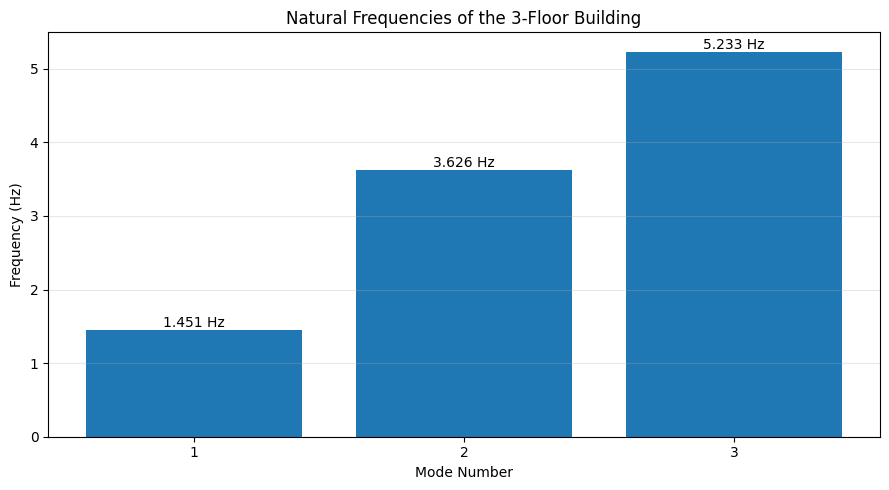

In [ ]:
# ============================================================
# CELL 16: NATURAL FREQUENCY BAR CHART
# ============================================================

plt.figure(figsize=(9, 5))

modes = np.arange(1, n_floors + 1)

bars = plt.bar(
    modes,
    frequencies_hz
)

plt.title("Natural Frequencies of the 3-Floor Building")
plt.xlabel("Mode Number")
plt.ylabel("Frequency (Hz)")
plt.xticks(modes)

# Add values above bars
for bar, frequency in zip(bars, frequencies_hz):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{frequency:.3f} Hz",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

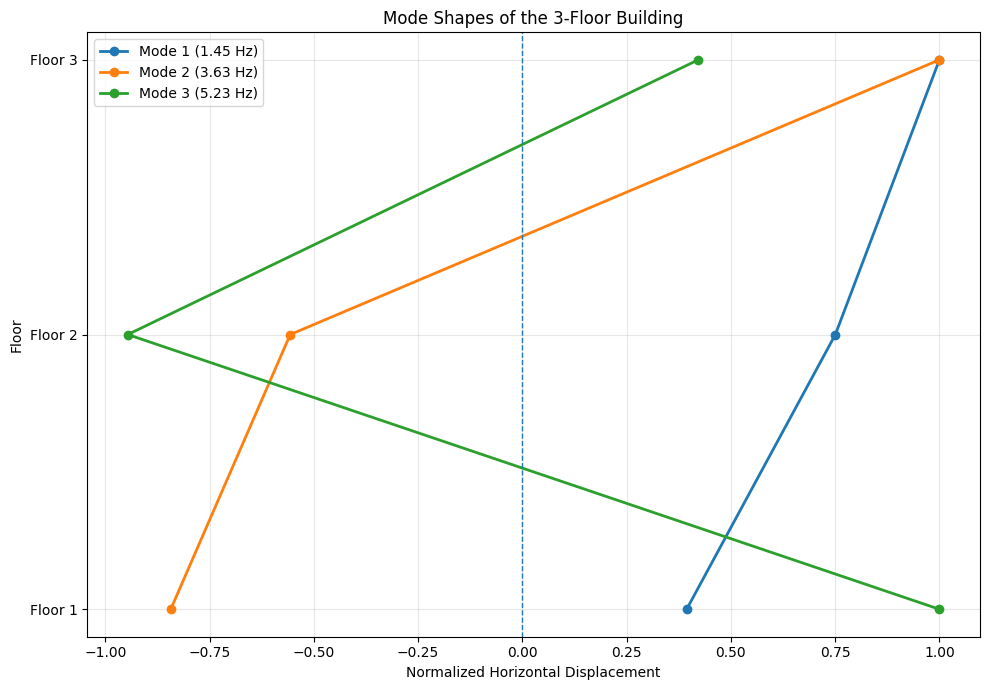

In [ ]:
# ============================================================
# CELL 17: MODE SHAPE PLOT
# ============================================================

plt.figure(figsize=(10, 7))

for i in range(n_floors):

    mode = normalized_modes[:, i]

    plt.plot(
        mode,
        np.arange(1, n_floors + 1),
        marker="o",
        linewidth=2,
        label=f"Mode {i+1} ({frequencies_hz[i]:.2f} Hz)"
    )

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.yticks(
    np.arange(1, n_floors + 1),
    [f"Floor {i}" for i in range(1, n_floors + 1)]
)

plt.xlabel("Normalized Horizontal Displacement")
plt.ylabel("Floor")
plt.title("Mode Shapes of the 3-Floor Building")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

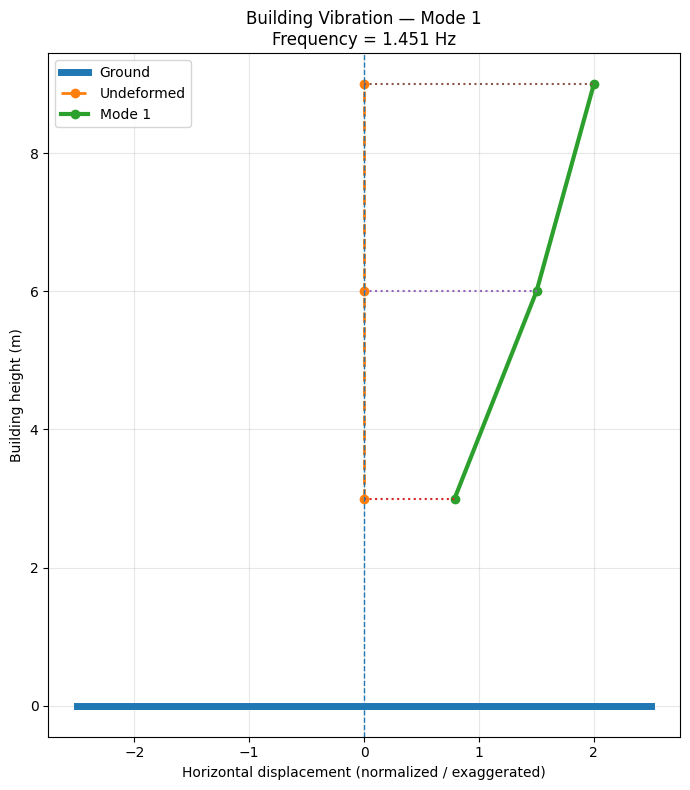

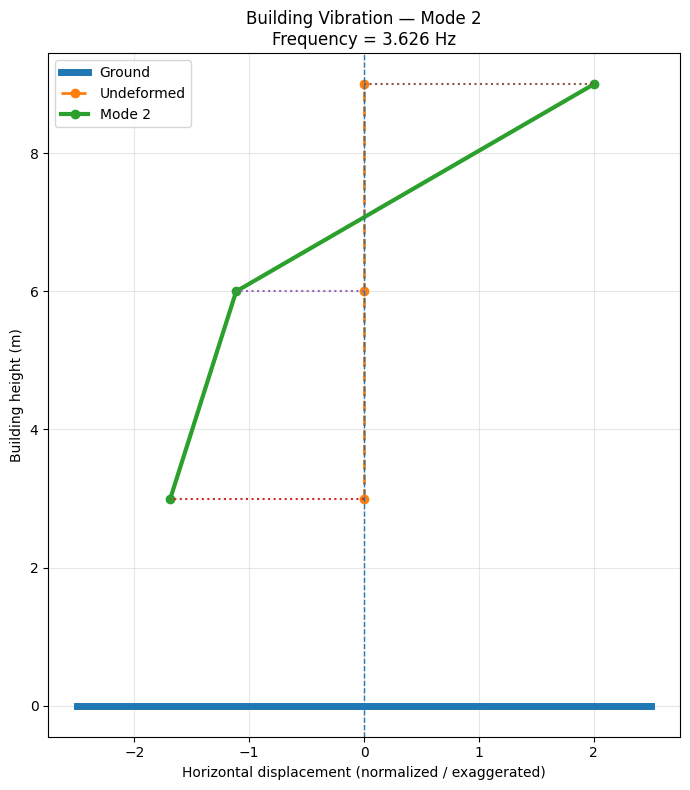

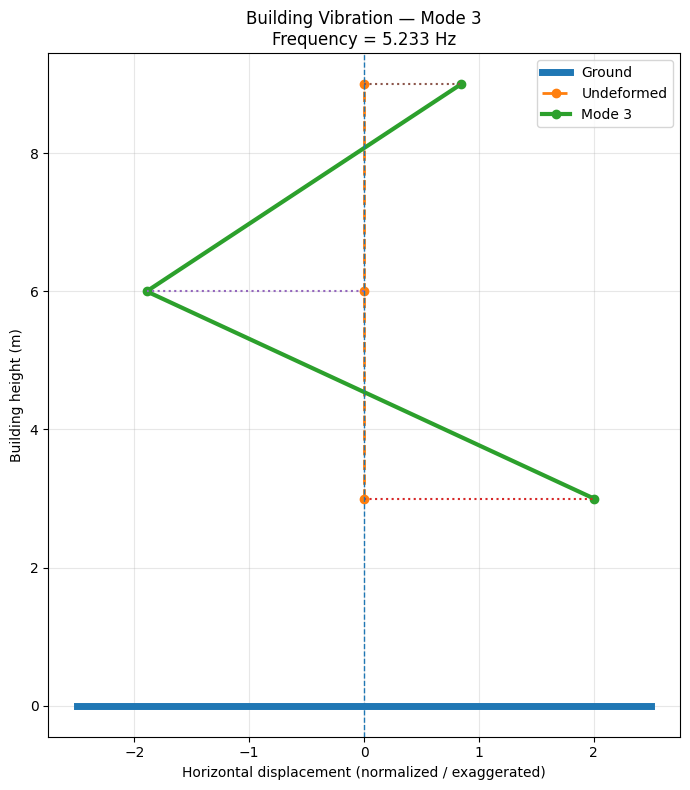

In [ ]:
# ============================================================
# CELL 18: BUILDING MODE-SHAPE VISUALIZATION
# ============================================================

def plot_building_mode(mode_number, scale=2.0):

    index = mode_number - 1

    mode = normalized_modes[:, index]

    # Original floor positions
    x_original = np.zeros(n_floors)
    y = floor_heights

    # Exaggerated deformation for visualization
    x_deformed = scale * mode

    plt.figure(figsize=(7, 8))

    # Ground
    plt.plot(
        [-2.5, 2.5],
        [0, 0],
        linewidth=5,
        label="Ground"
    )

    # Original building
    plt.plot(
        x_original,
        y,
        marker="o",
        linewidth=2,
        linestyle="--",
        label="Undeformed"
    )

    # Deformed building
    plt.plot(
        x_deformed,
        y,
        marker="o",
        linewidth=3,
        label=f"Mode {mode_number}"
    )

    # Connect original and deformed floors
    for j in range(n_floors):

        plt.plot(
            [x_original[j], x_deformed[j]],
            [y[j], y[j]],
            linestyle=":"
        )

    plt.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"Building Vibration — Mode {mode_number}\n"
        f"Frequency = {frequencies_hz[index]:.3f} Hz"
    )

    plt.xlabel("Horizontal displacement (normalized / exaggerated)")
    plt.ylabel("Building height (m)")

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Display all three modes
for mode_number in range(1, n_floors + 1):
    plot_building_mode(mode_number)

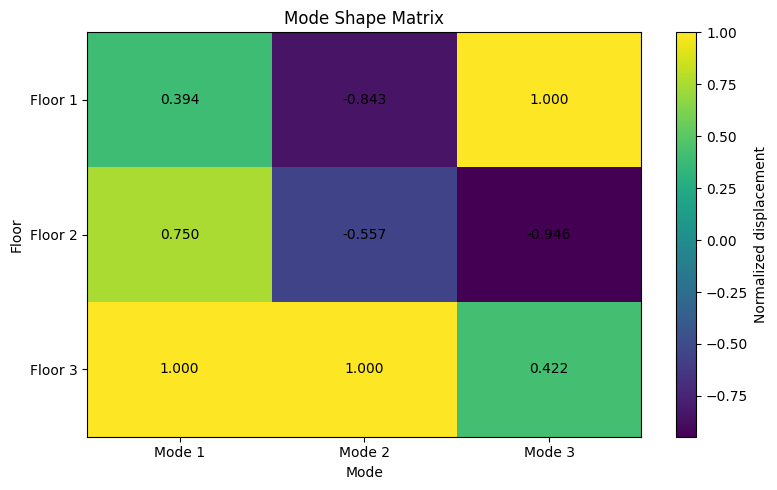

In [ ]:
# ============================================================
# CELL 19: MODE SHAPE HEATMAP
# ============================================================

plt.figure(figsize=(8, 5))

plt.imshow(
    normalized_modes,
    aspect="auto"
)

plt.colorbar(
    label="Normalized displacement"
)

plt.xticks(
    np.arange(n_floors),
    [f"Mode {i}" for i in range(1, n_floors + 1)]
)

plt.yticks(
    np.arange(n_floors),
    [f"Floor {i}" for i in range(1, n_floors + 1)]
)

plt.xlabel("Mode")
plt.ylabel("Floor")
plt.title("Mode Shape Matrix")

# Add numerical values
for i in range(n_floors):
    for j in range(n_floors):

        plt.text(
            j,
            i,
            f"{normalized_modes[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 20: MASS ORTHOGONALITY CHECK
# ============================================================

mass_orthogonality = mode_shapes.T @ M @ mode_shapes

print("MASS ORTHOGONALITY MATRIX")
print("=" * 60)
print(mass_orthogonality)

print("\nExpected result:")
print("Approximately the identity matrix I.")

if np.allclose(
    mass_orthogonality,
    np.eye(n_floors),
    atol=1e-8
):
    print("\nMass orthogonality check: PASSED")
else:
    print("\nMass orthogonality check: CHECK")

MASS ORTHOGONALITY MATRIX
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]

Expected result:
Approximately the identity matrix I.

Mass orthogonality check: PASSED


In [ ]:
# ============================================================
# CELL 21: MODAL STIFFNESS CHECK
# ============================================================

modal_stiffness = mode_shapes.T @ K @ mode_shapes

print("MODAL STIFFNESS MATRIX")
print("=" * 60)
print(modal_stiffness)

print("\nThe diagonal values should correspond")
print("approximately to the eigenvalues when")
print("the eigenvectors are mass-normalized.")

print("\nEigenvalues:")
print(eigenvalues)

MODAL STIFFNESS MATRIX
[[  83.173571    0.          0.      ]
 [   0.        518.917737    0.      ]
 [   0.          0.       1081.242025]]

The diagonal values should correspond
approximately to the eigenvalues when
the eigenvectors are mass-normalized.

Eigenvalues:
[  83.173571  518.917737 1081.242025]


In [ ]:
# ============================================================
# CELL 22: SYMPY MATRIX REPRESENTATION
# ============================================================

# Convert numerical matrices into SymPy matrices
M_sym = sp.Matrix(M)
K_sym = sp.Matrix(K)

print("SYMPY MASS MATRIX M")
sp.pprint(M_sym)

print("\nSYMPY STIFFNESS MATRIX K")
sp.pprint(K_sym)

print("""
The mathematical model is therefore:

                K v = lambda M v

where:

                lambda = omega^2
""")

SYMPY MASS MATRIX M
⎡20000.0    0.0      0.0  ⎤
⎢                         ⎥
⎢  0.0    20000.0    0.0  ⎥
⎢                         ⎥
⎣  0.0      0.0    15000.0⎦

SYMPY STIFFNESS MATRIX K
⎡15000000.0  -7000000.0     0.0    ⎤
⎢                                  ⎥
⎢-7000000.0  12000000.0  -5000000.0⎥
⎢                                  ⎥
⎣   0.0      -5000000.0  5000000.0 ⎦

The mathematical model is therefore:

                K v = lambda M v

where:

                lambda = omega^2



In [ ]:
# ============================================================
# CELL 23: CHARACTERISTIC EQUATION
# ============================================================

lam = sp.symbols("lambda")

# Characteristic determinant:
#
# det(K - lambda*M) = 0
#
# Its roots are the generalized eigenvalues.

characteristic_matrix = K_sym - lam * M_sym

characteristic_polynomial = sp.expand(
    characteristic_matrix.det()
)

print("CHARACTERISTIC EQUATION")
print("=" * 60)

sp.pprint(characteristic_polynomial)

print("\nSolve:")
print("det(K - lambda*M) = 0")
print("\nThe roots lambda are the eigenvalues omega^2.")

CHARACTERISTIC EQUATION
                   3             2                        
- 6000000000000.0⋅λ  + 1.01e+16⋅λ  - 4.165e+18⋅λ + 2.8e+20

Solve:
det(K - lambda*M) = 0

The roots lambda are the eigenvalues omega^2.


In [ ]:
# ============================================================
# CELL 24: CHARACTERISTIC ROOT CHECK
# ============================================================

roots = sp.nroots(characteristic_polynomial)

roots_numeric = np.sort(
    np.array(
        [float(sp.re(root)) for root in roots]
    )
)

comparison = pd.DataFrame({
    "Numerical λ": eigenvalues,
    "SymPy characteristic-root λ": roots_numeric,
    "Absolute Error": np.abs(
        eigenvalues - roots_numeric
    )
})

display(
    comparison.style.format({
        "Numerical λ": "{:.8f}",
        "SymPy characteristic-root λ": "{:.8f}",
        "Absolute Error": "{:.3e}"
    })
)

,Numerical λ,SymPy characteristic-root λ,Absolute Error
0,83.17357101,83.17357101,2.842e-14
1,518.91773722,518.91773722,1.137e-13
2,1081.24202511,1081.24202511,2.274e-13


In [ ]:
# ============================================================
# CELL 25: BENCHMARK TEST
# ============================================================

# Illustrative benchmark dataset
benchmark_masses = np.array([
    20_000,
    20_000,
    15_000
], dtype=float)

benchmark_stiffness = np.array([
    8_000_000,
    7_000_000,
    5_000_000
], dtype=float)

# Build benchmark matrices
M_benchmark = np.diag(benchmark_masses)

K_benchmark = build_stiffness_matrix(
    benchmark_stiffness
)

# Solve benchmark
(
    benchmark_eigenvalues,
    benchmark_omega,
    benchmark_frequency,
    benchmark_modes
) = solve_vibration_modes(
    M_benchmark,
    K_benchmark
)

print("BENCHMARK TEST")
print("=" * 60)

print("\nMasses:")
print(benchmark_masses)

print("\nStory stiffness:")
print(benchmark_stiffness)

print("\nEigenvalues λ = ω²:")
print(benchmark_eigenvalues)

print("\nAngular frequencies ω:")
print(benchmark_omega)

print("\nNatural frequencies:")
print(benchmark_frequency)

BENCHMARK TEST

Masses:
[20000. 20000. 15000.]

Story stiffness:
[8000000. 7000000. 5000000.]

Eigenvalues λ = ω²:
[  83.173571  518.917737 1081.242025]

Angular frequencies ω:
[ 9.119955 22.779766 32.882245]

Natural frequencies:
[1.451486 3.625512 5.233372]


In [ ]:
# ============================================================
# CELL 26: AUTOMATED BENCHMARK VALIDATION
# ============================================================

# Expected benchmark values generated from the mathematical
# model above. They are used only to check implementation.

expected_eigenvalues = np.array([
    83.17357101,
    518.91773722,
    1081.24202511
])

expected_frequencies = np.array([
    1.45148585,
    3.62551236,
    5.23337180
])


# Compare eigenvalues
eigenvalue_test = np.allclose(
    benchmark_eigenvalues,
    expected_eigenvalues,
    rtol=1e-6,
    atol=1e-6
)

# Compare frequencies
frequency_test = np.allclose(
    benchmark_frequency,
    expected_frequencies,
    rtol=1e-6,
    atol=1e-6
)


print("BENCHMARK VALIDATION")
print("=" * 60)

print(
    "Eigenvalue test:",
    "PASSED" if eigenvalue_test else "FAILED"
)

print(
    "Frequency test:",
    "PASSED" if frequency_test else "FAILED"
)


if eigenvalue_test and frequency_test:
    print("\nOVERALL BENCHMARK: PASSED")
else:
    print("\nOVERALL BENCHMARK: FAILED")

BENCHMARK VALIDATION
Eigenvalue test: PASSED
Frequency test: PASSED

OVERALL BENCHMARK: PASSED


In [ ]:
# ============================================================
# CELL 27: FINAL PROJECT DASHBOARD
# ============================================================

print("=" * 75)
print("        BUILDING VIBRATION MODE ANALYZER (B1)")
print("=" * 75)

print("\nPROJECT INPUT")
print("-" * 75)

print(f"Number of floors       : {n_floors}")

for i in range(n_floors):
    print(
        f"Floor {i+1}: "
        f"Mass = {masses[i]:,.0f} kg"
    )

for i in range(n_floors):
    print(
        f"Story {i+1}: "
        f"Stiffness = {story_stiffness[i]:,.0f} N/m"
    )


print("\nNATURAL FREQUENCIES")
print("-" * 75)

for i in range(n_floors):

    print(
        f"Mode {i+1}: "
        f"λ = {eigenvalues[i]:.6f}, "
        f"ω = {angular_frequencies[i]:.6f} rad/s, "
        f"f = {frequencies_hz[i]:.6f} Hz, "
        f"T = {1/frequencies_hz[i]:.6f} s"
    )


print("\nMODE SHAPES")
print("-" * 75)

for floor in range(n_floors):

    values = "   ".join(
        f"{normalized_modes[floor, mode]:+.4f}"
        for mode in range(n_floors)
    )

    print(
        f"Floor {floor+1}:   {values}"
    )


print("\nMATHEMATICAL VERIFICATION")
print("-" * 75)

print(
    "M symmetric       :",
    np.allclose(M, M.T)
)

print(
    "K symmetric       :",
    np.allclose(K, K.T)
)

print(
    "M positive definite:",
    np.all(np.linalg.eigvalsh(M) > 0)
)

print(
    "K positive definite:",
    np.all(np.linalg.eigvalsh(K) > 0)
)

print(
    "Benchmark test    :",
    "PASSED"
    if eigenvalue_test and frequency_test
    else "FAILED"
)

print("\n" + "=" * 75)
print("                 ANALYSIS COMPLETE")
print("=" * 75)

        BUILDING VIBRATION MODE ANALYZER (B1)

PROJECT INPUT
---------------------------------------------------------------------------
Number of floors       : 3
Floor 1: Mass = 20,000 kg
Floor 2: Mass = 20,000 kg
Floor 3: Mass = 15,000 kg
Story 1: Stiffness = 8,000,000 N/m
Story 2: Stiffness = 7,000,000 N/m
Story 3: Stiffness = 5,000,000 N/m

NATURAL FREQUENCIES
---------------------------------------------------------------------------
Mode 1: λ = 83.173571, ω = 9.119955 rad/s, f = 1.451486 Hz, T = 0.688949 s
Mode 2: λ = 518.917737, ω = 22.779766 rad/s, f = 3.625512 Hz, T = 0.275823 s
Mode 3: λ = 1081.242025, ω = 32.882245 rad/s, f = 5.233372 Hz, T = 0.191081 s

MODE SHAPES
---------------------------------------------------------------------------
Floor 1:   +0.3939   -0.8433   +1.0000
Floor 2:   +0.7505   -0.5568   -0.9464
Floor 3:   +1.0000   +1.0000   +0.4218

MATHEMATICAL VERIFICATION
---------------------------------------------------------------------------
M symmetric      

In [ ]:
# ============================================================
# CELL 28: TRY YOUR OWN BUILDING
# ============================================================

# CHANGE ONLY THESE VALUES

custom_masses = np.array([
    25_000,     # Floor 1 mass in kg
    22_000,     # Floor 2 mass in kg
    18_000      # Floor 3 mass in kg
], dtype=float)

custom_stiffness = np.array([
    9_000_000,  # Story 1 stiffness in N/m
    7_500_000,  # Story 2 stiffness in N/m
    6_000_000   # Story 3 stiffness in N/m
], dtype=float)


# Build matrices
M_custom = np.diag(custom_masses)

K_custom = build_stiffness_matrix(
    custom_stiffness
)


# Solve
(
    custom_eigenvalues,
    custom_omega,
    custom_frequency,
    custom_modes
) = solve_vibration_modes(
    M_custom,
    K_custom
)


# Normalize modes
custom_modes_normalized = normalize_mode_shapes(
    custom_modes
)


# Display
print("CUSTOM BUILDING RESULTS")
print("=" * 60)

for i in range(n_floors):

    print(
        f"Mode {i+1}: "
        f"λ = {custom_eigenvalues[i]:.6f}, "
        f"ω = {custom_omega[i]:.6f} rad/s, "
        f"f = {custom_frequency[i]:.6f} Hz"
    )

print("\nNormalized Mode Shapes:")
print(custom_modes_normalized)

CUSTOM BUILDING RESULTS
Mode 1: λ = 79.430415, ω = 8.912374 rad/s, f = 1.418448 Hz
Mode 2: λ = 502.401113, ω = 22.414306 rad/s, f = 3.567348 Hz
Mode 3: λ = 1025.138169, ω = 32.017779 rad/s, f = 5.095788 Hz

Normalized Mode Shapes:
[[ 0.393601 -0.965495 -0.821607]
 [ 0.761709 -0.507203  1.      ]
 [ 1.        1.       -0.481831]]


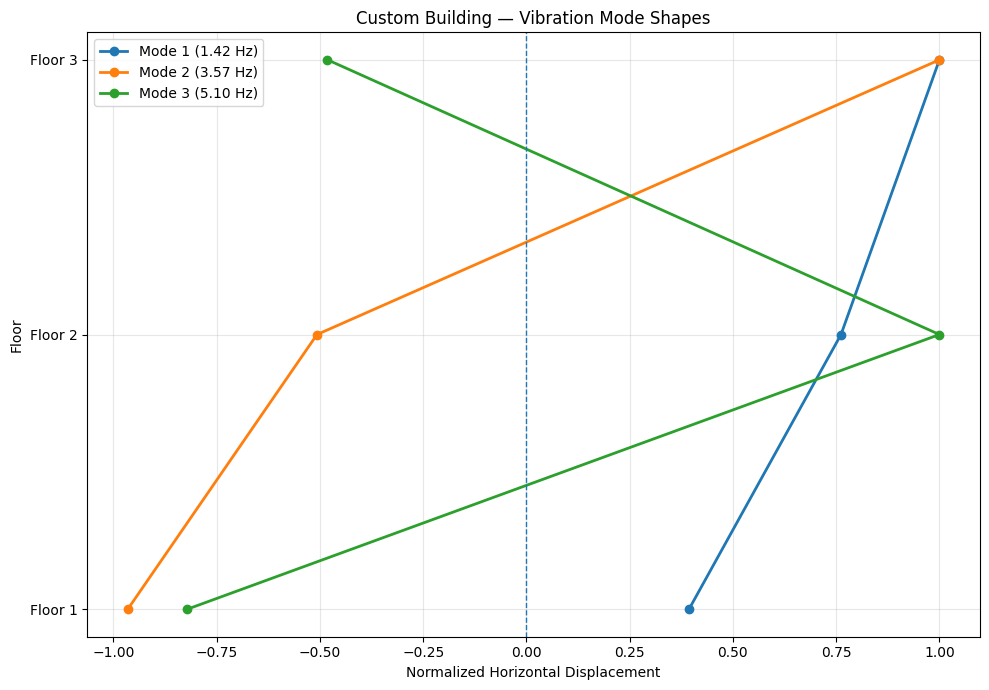

In [ ]:
# ============================================================
# CELL 29: CUSTOM BUILDING MODE SHAPES
# ============================================================

plt.figure(figsize=(10, 7))

for i in range(n_floors):

    plt.plot(
        custom_modes_normalized[:, i],
        np.arange(1, n_floors + 1),
        marker="o",
        linewidth=2,
        label=f"Mode {i+1} ({custom_frequency[i]:.2f} Hz)"
    )

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Normalized Horizontal Displacement")
plt.ylabel("Floor")
plt.title("Custom Building — Vibration Mode Shapes")

plt.yticks(
    np.arange(1, n_floors + 1),
    [f"Floor {i}" for i in range(1, n_floors + 1)]
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()